# Análisis de datos y exploración Pregunta 2

In [17]:
import numpy as np
import pandas as pd 

## Carga de dataframe 

In [ ]:
with open("icfes_cols_filtered_no_dupes_BOM(in).csv", encoding="utf-8-sig") as f:
    text = f.read()

text = text.replace('"', '')

with open("archivo_limpio.csv", "w", encoding="utf-8") as f:
    f.write(text)

df = pd.read_csv("archivo_limpio.csv", sep=",")

print(df.shape)
print(df.columns)

(125185, 17)
Index(['periodo', 'estu_consecutivo', 'cole_area_ubicacion', 'cole_calendario',
       'cole_cod_dane_sede', 'cole_jornada', 'cole_naturaleza',
       'cole_nombre_sede', 'fami_educacionmadre', 'fami_educacionpadre',
       'desemp_ingles', 'punt_ingles', 'punt_matematicas',
       'punt_sociales_ciudadanas', 'punt_c_naturales', 'punt_lectura_critica',
       'punt_global'],
      dtype='object')


In [24]:
df_p2 = df[['punt_global', 'fami_educacionmadre', 'fami_educacionpadre']]
print(df_p2.head())

   punt_global                   fami_educacionmadre  \
0        183.0                     Primaria completa   
1        234.0                     Primaria completa   
2        195.0                   Primaria incompleta   
3        283.0        Educación profesional completa   
4        183.0  Secundaria (Bachillerato) incompleta   

                  fami_educacionpadre  
0                   Primaria completa  
1                   Primaria completa  
2                   Primaria completa  
3      Educación profesional completa  
4  Secundaria (Bachillerato) completa  


## Análisis de datos

### Categorías de eduación

#### Categorías Madre

In [41]:
lm = list(df['fami_educacionmadre'].unique())
print(lm)
print(len(lm))

['Primaria completa', 'Primaria incompleta', 'Educación profesional completa', 'Secundaria (Bachillerato) incompleta', 'Secundaria (Bachillerato) completa', 'Técnica o tecnológica completa', 'Postgrado', 'Educación profesional incompleta', 'Técnica o tecnológica incompleta', nan, 'Ninguno', 'No sabe', 'No Aplica']
13


#### Categorías Padre

In [42]:
lp = list(df['fami_educacionpadre'].unique())
print(lp)
print(len(lp))

['Primaria completa', 'Educación profesional completa', 'Secundaria (Bachillerato) completa', 'Secundaria (Bachillerato) incompleta', 'No sabe', 'Primaria incompleta', 'Educación profesional incompleta', 'Técnica o tecnológica completa', 'Postgrado', 'Técnica o tecnológica incompleta', 'Ninguno', nan, 'No Aplica']
13


#### Comparación entre categorías

In [44]:
ne = []
e = []
for i in lm:
    if i in lp:
        e.append(i)
    else:
        ne.append(i)
print("Cantidad de categorias que coinciden entre madre y padre:", len(e))
if len(e) > 0:
    print("Categorías que coinciden entre madre y padre:")
    for categoria in e:
        print(categoria)

print("Cantidad de categorias que no coinciden entre madre y padre:", len(ne))
if len(ne) > 0:
    print("Categorías que no coinciden entre madre y padre:")
    for categoria in ne:
        print(categoria)    

Cantidad de categorias que coinciden entre madre y padre: 13
Categorías que coinciden entre madre y padre:
Primaria completa
Primaria incompleta
Educación profesional completa
Secundaria (Bachillerato) incompleta
Secundaria (Bachillerato) completa
Técnica o tecnológica completa
Postgrado
Educación profesional incompleta
Técnica o tecnológica incompleta
nan
Ninguno
No sabe
No Aplica
Cantidad de categorias que no coinciden entre madre y padre: 0


### Educación madre

In [45]:
print(df['fami_educacionmadre'].value_counts().sort_values(ascending=False))

fami_educacionmadre
Secundaria (Bachillerato) completa      33134
Primaria incompleta                     18377
Secundaria (Bachillerato) incompleta    17980
Primaria completa                       16993
Educación profesional completa          12129
Técnica o tecnológica completa          10298
Ninguno                                  4346
Técnica o tecnológica incompleta         2739
No sabe                                  2343
Educación profesional incompleta         2048
Postgrado                                1735
No Aplica                                  76
Name: count, dtype: int64


In [47]:
df.groupby('fami_educacionmadre')['punt_global'].mean().sort_values(ascending=False)

fami_educacionmadre
Postgrado                               300.668831
Educación profesional completa          272.868739
Educación profesional incompleta        267.978157
Técnica o tecnológica completa          258.823682
Técnica o tecnológica incompleta        249.686022
No sabe                                 243.753247
Secundaria (Bachillerato) completa      242.704780
Secundaria (Bachillerato) incompleta    236.145714
Primaria completa                       229.138402
Primaria incompleta                     227.140006
Ninguno                                 221.609467
No Aplica                               212.315789
Name: punt_global, dtype: float64

In [31]:
df.groupby('fami_educacionmadre')['punt_global'].describe()

,count,mean,std,min,25%,50%,75%,max
fami_educacionmadre,,,,,,,,
Educación profesional completa,7946.0,272.868739,52.936613,134.0,234.00,271.0,311.0,458.0
Educación profesional incompleta,1465.0,267.978157,51.887550,143.0,229.00,266.0,305.0,465.0
Ninguno,2535.0,221.609467,38.487041,128.0,194.00,217.0,247.0,368.0
No Aplica,76.0,212.315789,42.960512,152.0,177.75,199.5,237.0,320.0
No sabe,1309.0,243.753247,52.034005,18.0,204.00,237.0,277.0,404.0
Postgrado,1078.0,300.668831,56.428464,131.0,261.00,304.0,342.0,438.0
Primaria completa,8562.0,229.138402,37.894574,0.0,202.00,226.0,253.0,408.0
Primaria incompleta,10821.0,227.140006,36.800324,65.0,200.00,224.0,251.0,410.0
Secundaria (Bachillerato) completa,20544.0,242.704780,42.395594,87.0,212.00,239.0,270.0,465.0


### Educación padre

In [48]:
print(df['fami_educacionpadre'].value_counts().sort_values(ascending=False))

fami_educacionpadre
Secundaria (Bachillerato) completa      30625
Primaria incompleta                     21436
Primaria completa                       17060
Secundaria (Bachillerato) incompleta    16188
Educación profesional completa          11655
Técnica o tecnológica completa           7411
Ninguno                                  7041
No sabe                                  4807
Técnica o tecnológica incompleta         2272
Educación profesional incompleta         1817
Postgrado                                1648
No Aplica                                 274
Name: count, dtype: int64


In [49]:
df.groupby('fami_educacionpadre')['punt_global'].mean().sort_values(ascending=False)

fami_educacionpadre
Postgrado                               304.245580
Educación profesional completa          272.323478
Educación profesional incompleta        267.369672
Técnica o tecnológica completa          260.445763
No sabe                                 249.074866
Técnica o tecnológica incompleta        247.381275
Secundaria (Bachillerato) completa      244.640989
No Aplica                               240.897810
Secundaria (Bachillerato) incompleta    236.523772
Primaria completa                       230.611634
Primaria incompleta                     230.505534
Ninguno                                 224.400000
Name: punt_global, dtype: float64

In [50]:
df.groupby('fami_educacionpadre')['punt_global'].describe()

,count,mean,std,min,25%,50%,75%,max
fami_educacionpadre,,,,,,,,
Educación profesional completa,7373.0,272.323478,51.916004,133.0,235.00,271.0,309.0,458.0
Educación profesional incompleta,1220.0,267.369672,50.665629,139.0,229.75,266.0,305.0,431.0
Ninguno,4275.0,224.400000,38.441077,128.0,196.00,220.0,249.0,383.0
No Aplica,274.0,240.897810,54.095531,138.0,198.00,237.0,277.0,391.0
No sabe,2992.0,249.074866,49.044338,18.0,212.00,245.0,281.0,427.0
Postgrado,1018.0,304.245580,57.118953,151.0,265.00,309.0,345.0,465.0
Primaria completa,8716.0,230.611634,38.178087,0.0,203.00,227.0,255.0,408.0
Primaria incompleta,13101.0,230.505534,37.794849,65.0,203.00,227.0,255.0,465.0
Secundaria (Bachillerato) completa,19005.0,244.640989,43.476779,87.0,213.00,241.0,273.0,447.0


## Visualizaciones

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
orden = [
    '-',
    'Ninguno',
    'Primaria incompleta',
    'Primaria completa',
    'Secundaria (Bachillerato) incompleta',
    'Secundaria (Bachillerato) completa',
    'Técnica o tecnológica incompleta',
    'Técnica o tecnológica completa',
    'Educación profesional incompleta',
    'Educación profesional completa',
    'Postgrado',
    'No sabe',
    'No Aplica'
]

### Eduación Madre

In [61]:
df['fami_educacionmadre'] = (
    df['fami_educacionmadre']
    .str.replace('"', '')
    .str.strip()
    .fillna('-')
)

df['fami_educacionmadre'] = pd.Categorical(
    df['fami_educacionmadre'],
    categories=orden,
    ordered=True
)

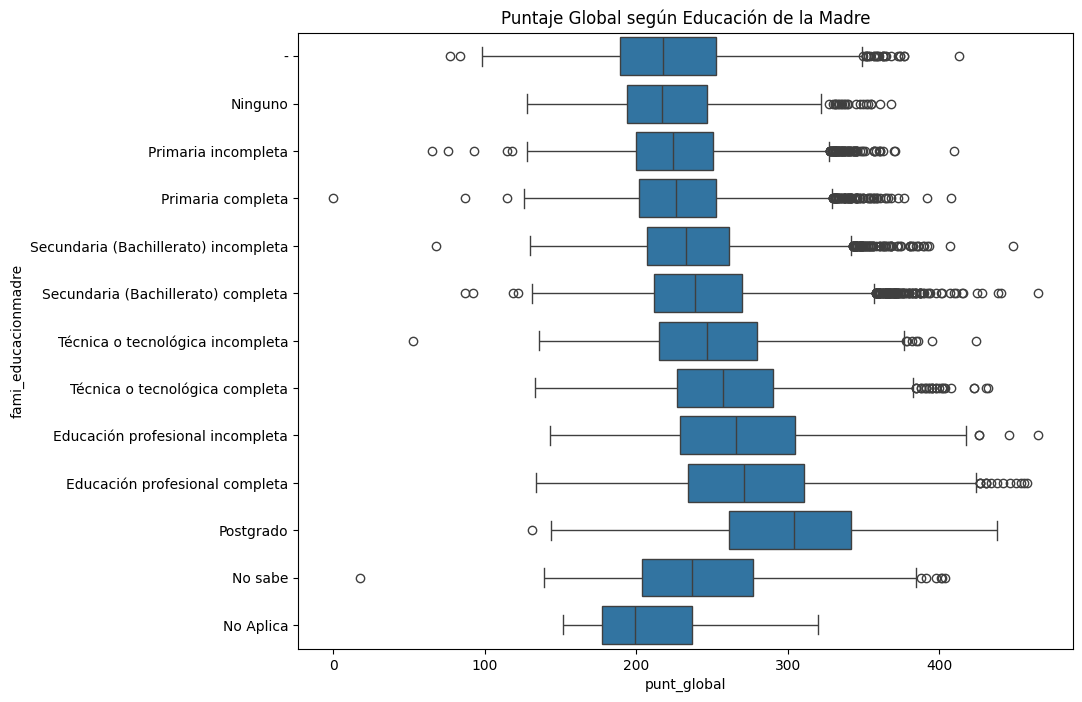

In [62]:
plt.figure(figsize=(10,8))
sns.boxplot(
    y='fami_educacionmadre',
    x='punt_global',
    data=df
)

plt.title("Puntaje Global según Educación de la Madre")
plt.show()

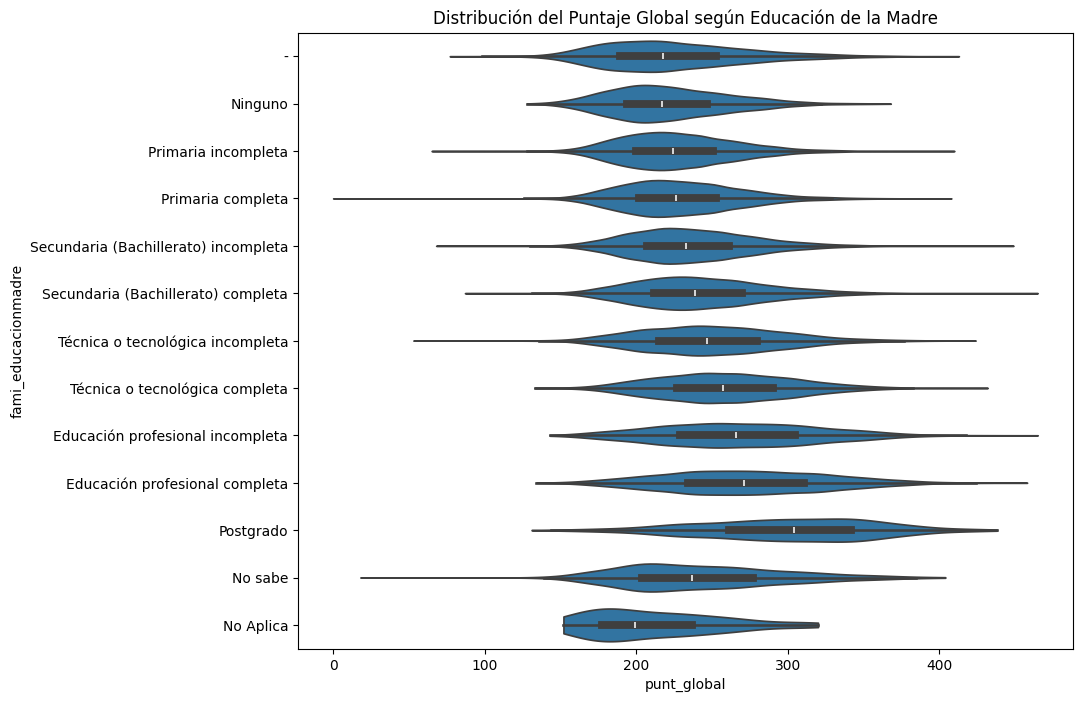

In [69]:
plt.figure(figsize=(10,8))

sns.violinplot(
    data=df,
    y='fami_educacionmadre',
    x='punt_global',
    order=orden,
    cut=0
)

plt.title("Distribución del Puntaje Global según Educación de la Madre")
plt.show()

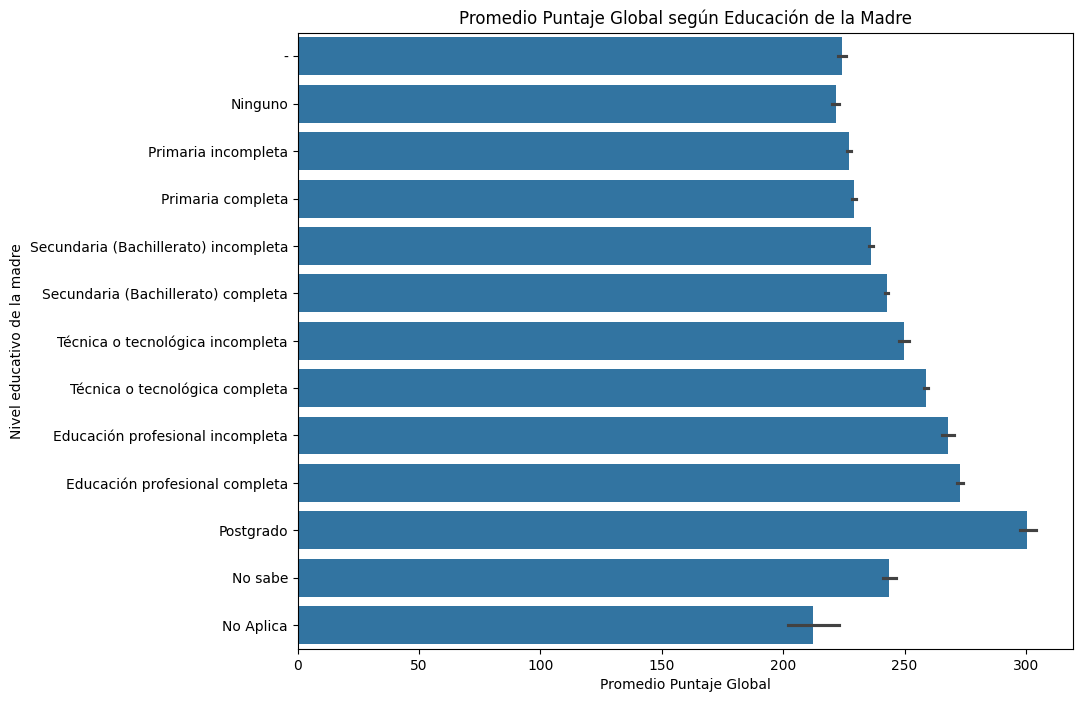

In [65]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=df,
    y='fami_educacionmadre',
    x='punt_global',
    estimator='mean'
)

plt.title("Promedio Puntaje Global según Educación de la Madre")
plt.xlabel("Promedio Puntaje Global")
plt.ylabel("Nivel educativo de la madre")

plt.show()

### Educación Padre

In [66]:
df['fami_educacionpadre'] = (
    df['fami_educacionpadre']
    .str.replace('"', '')
    .str.strip()
    .fillna('-')
)

df['fami_educacionpadre'] = pd.Categorical(
    df['fami_educacionpadre'],
    categories=orden,
    ordered=True
)

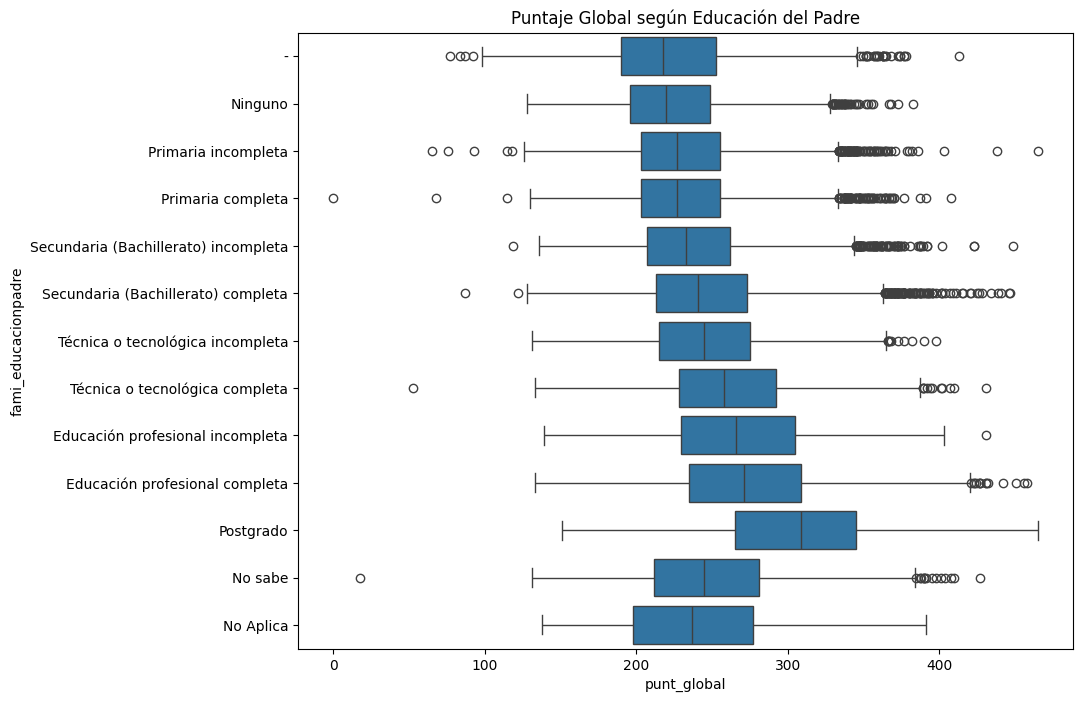

In [67]:
plt.figure(figsize=(10,8))
sns.boxplot(
    y='fami_educacionpadre',
    x='punt_global',
    data=df
)

plt.title("Puntaje Global según Educación del Padre")
plt.show()

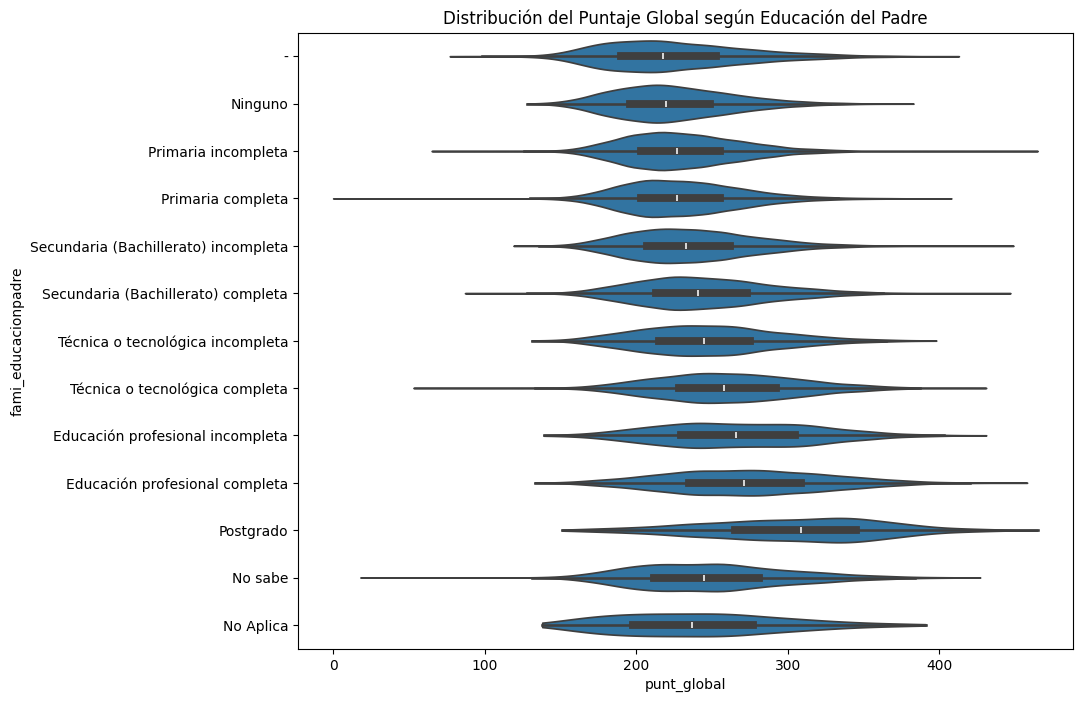

In [70]:
plt.figure(figsize=(10,8))

sns.violinplot(
    data=df,
    y='fami_educacionpadre',
    x='punt_global',
    order=orden,
    cut=0
)

plt.title("Distribución del Puntaje Global según Educación del Padre")
plt.show()

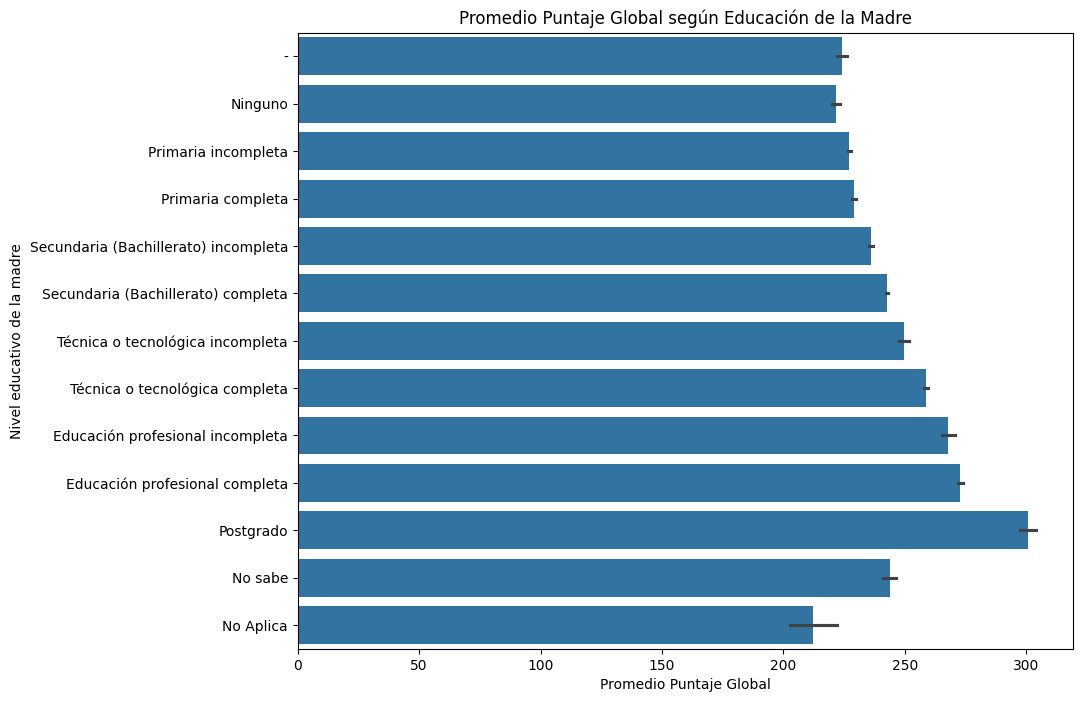

In [71]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=df,
    y='fami_educacionmadre',
    x='punt_global',
    estimator='mean'
)

plt.title("Promedio Puntaje Global según Educación de la Madre")
plt.xlabel("Promedio Puntaje Global")
plt.ylabel("Nivel educativo de la madre")

plt.show()

### Ambos

In [80]:
tabla = (
    df
    .groupby(
        ['fami_educacionmadre', 'fami_educacionpadre'],
        observed=True
    )['punt_global']
    .mean()
    .unstack()
)
tabla = tabla.reindex(index=orden, columns=orden)

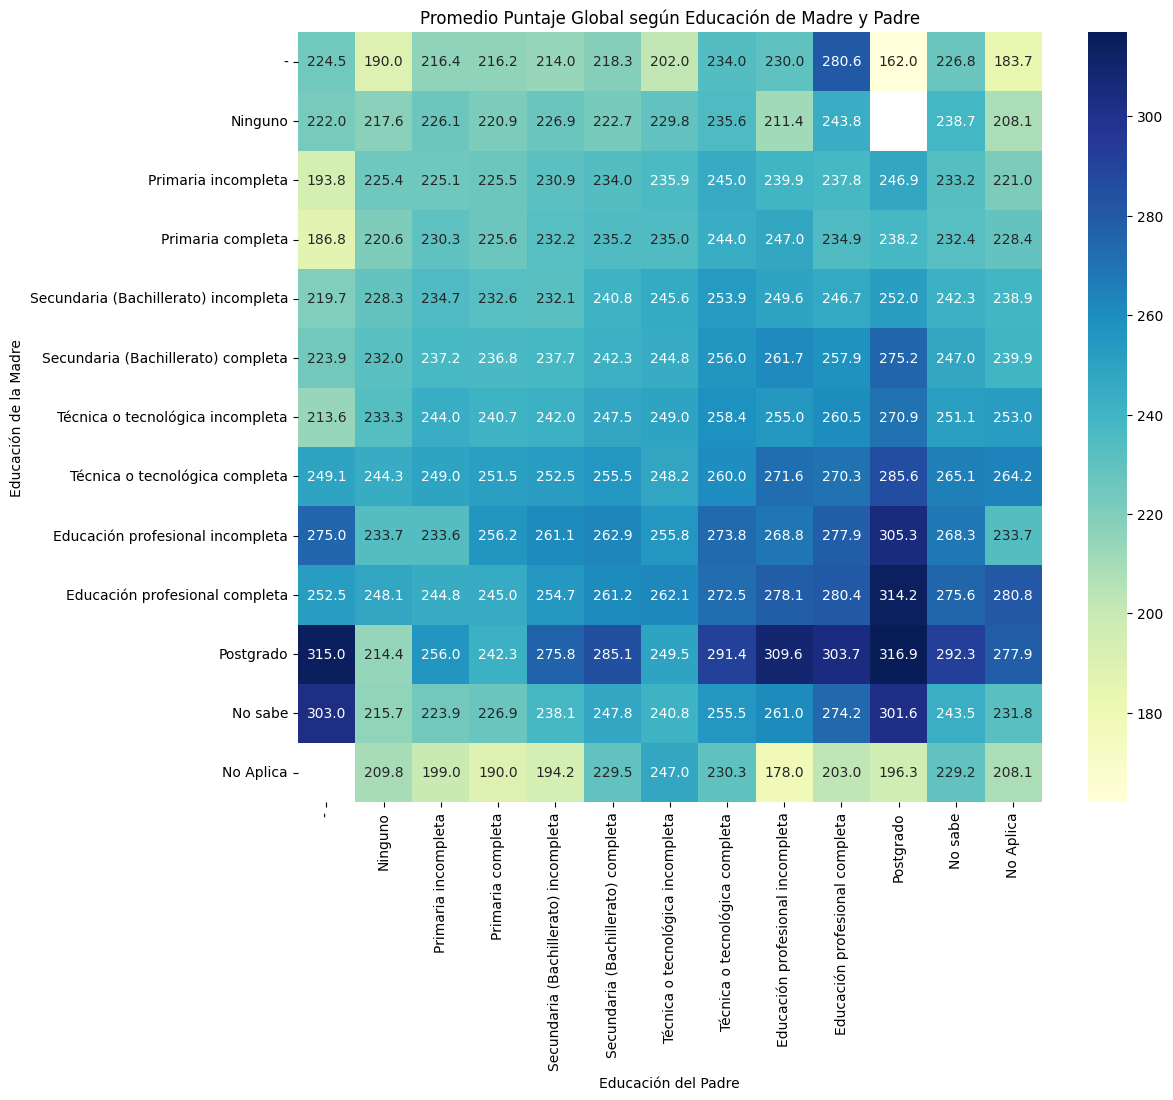

In [81]:
plt.figure(figsize=(12,10))

sns.heatmap(
    tabla,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Promedio Puntaje Global según Educación de Madre y Padre")
plt.xlabel("Educación del Padre")
plt.ylabel("Educación de la Madre")

plt.show()

In [82]:
df_largo = df.melt(
    id_vars='punt_global',
    value_vars=['fami_educacionmadre', 'fami_educacionpadre'],
    var_name='Tipo',
    value_name='Nivel_educativo'
)
df_largo['Tipo'] = df_largo['Tipo'].replace({
    'fami_educacionmadre': 'Madre',
    'fami_educacionpadre': 'Padre'
})

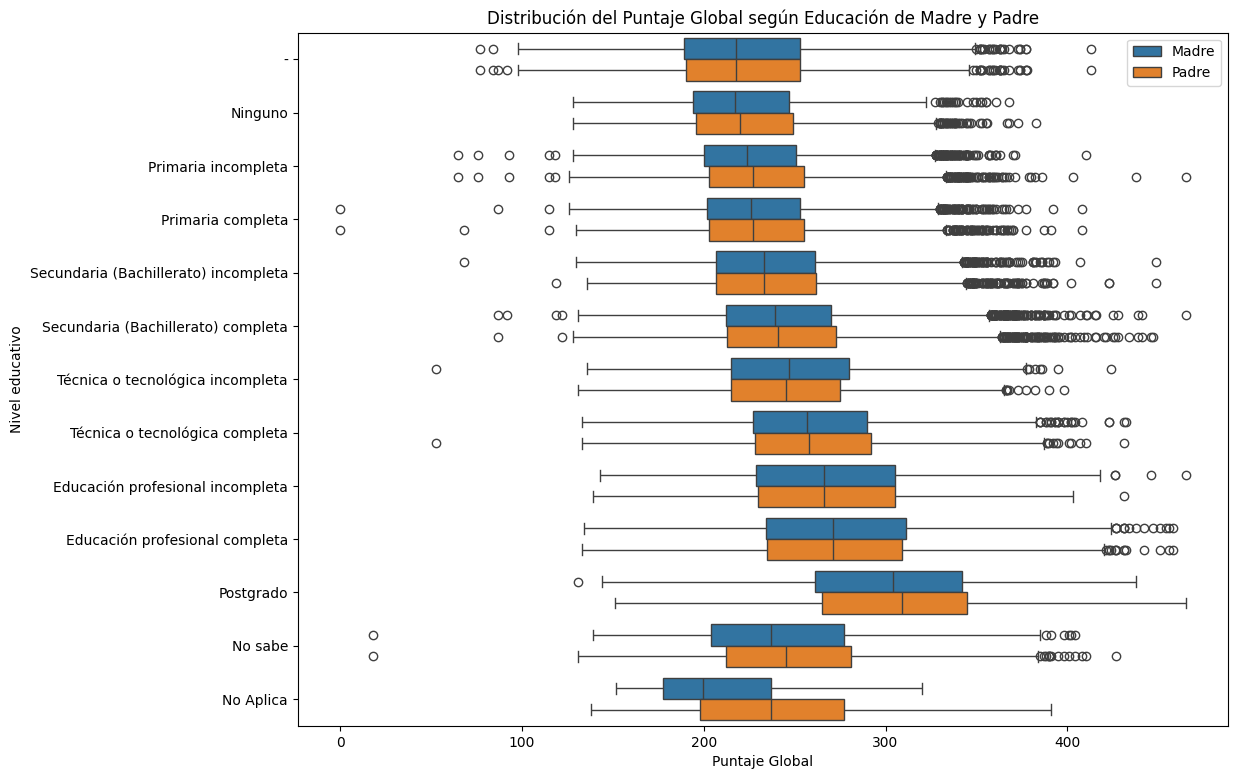

In [83]:
plt.figure(figsize=(12,9))

sns.boxplot(
    data=df_largo,
    y='Nivel_educativo',
    x='punt_global',
    hue='Tipo',
    order=orden
)

plt.title("Distribución del Puntaje Global según Educación de Madre y Padre")
plt.xlabel("Puntaje Global")
plt.ylabel("Nivel educativo")
plt.legend(title="")

plt.show()

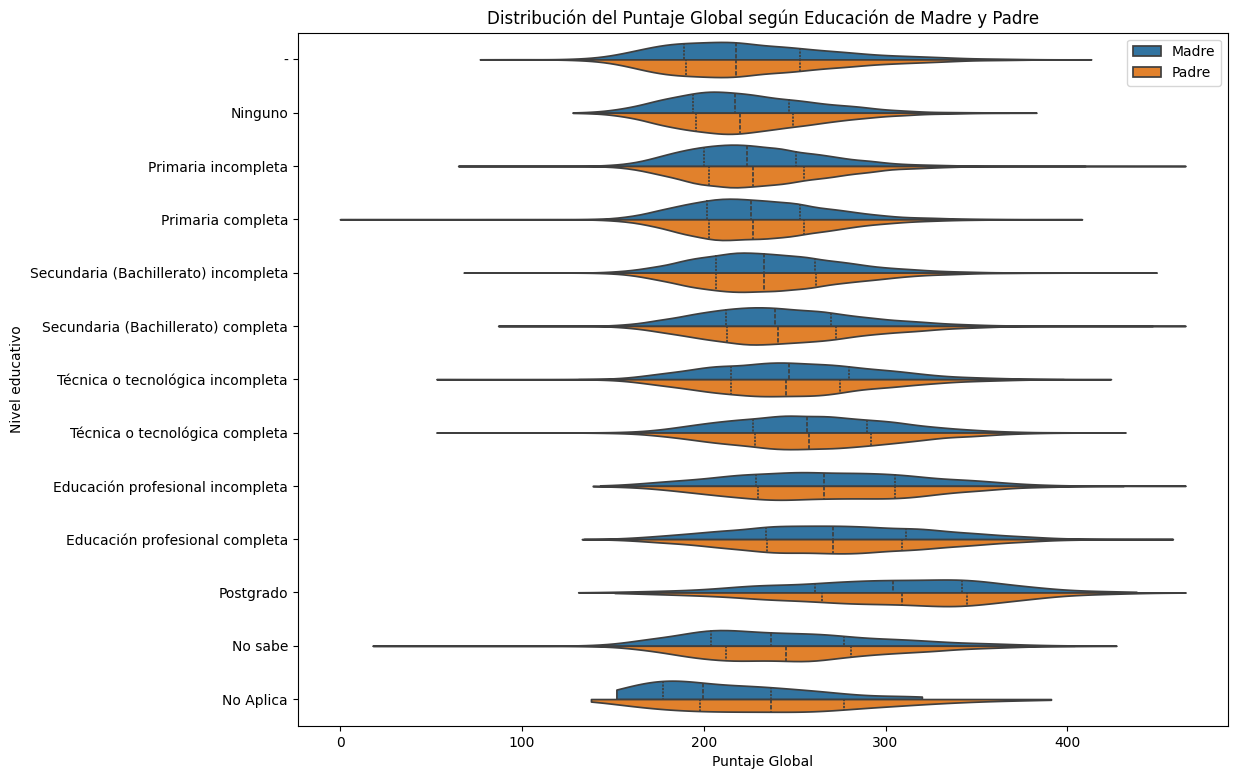

In [84]:
plt.figure(figsize=(12,9))

sns.violinplot(
    data=df_largo,
    y="Nivel_educativo",
    x="punt_global",
    hue="Tipo",
    split=True,
    inner="quart",
    order=orden,
    cut=0
)

plt.title("Distribución del Puntaje Global según Educación de Madre y Padre")
plt.xlabel("Puntaje Global")
plt.ylabel("Nivel educativo")
plt.legend(title="")

plt.show()